# 🦴 Hybrid Pipeline — ResNet U-Net + SAM Pretrain + Radiologist Refine + TTA

**Зорилго:** Литературын баримтлал (Dice 0.55-0.75) хүрэх **бодит хүчирхэг** pipeline.

## Pipeline 3 шат

| Шат | Дата | Зорилго | Хүлээгдэж буй Dice |
|---|---|---|---|
| **A. Pretrain** | 3K SAM маск | Fracture-ийн **ерөнхий feature** сурах | ~0.30 (SAM val) |
| **B. Refine** | 574 FracAtlas жинхэнэ маск | **Радиологичын стандарт** руу шилжих | ~0.50-0.65 (FracAtlas val) |
| **C. TTA inference** | FracAtlas test | Final score — augmentation + averaging | **~0.55-0.75** |

## Архитектур
- **Encoder:** ResNet50 (ImageNet pretrained, **23M params**)
- **Decoder:** U-Net стандарт
- **Loss:** Dice + BCE-with-logits
- **Library:** `segmentation_models_pytorch` (домэйн стандарт)

## Орох (Drive)
- `MyDrive/fracture_dataset_ready/{images, fracture_sam_final.json}` — 3K SAM
- `MyDrive/fracatlas-DatasetNinja/{train, val, test}/{ann, img}` — 574 жинхэнэ

## Гарах
- `MyDrive/hybrid_unet_pretrain.pth` — Шат A-ийн жин
- `MyDrive/hybrid_unet_final.pth` — Шат B-ийн жин (эцсийн)
- `MyDrive/hybrid_curves.png`, `MyDrive/hybrid_predictions.png`

> ⏱ **Хугацаа:** T4 GPU дээр ~1-1.5 цаг (A: ~40 мин, B: ~20 мин, C: ~5 мин)


In [1]:
# Сангуудыг суулгах
!pip install -q segmentation_models_pytorch albumentations==1.3.1 pycocotools


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.0 MB/s eta 0:00:00


In [2]:
# Drive холбох
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os, json, glob, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
import segmentation_models_pytorch as smp
from pycocotools.coco import COCO

import warnings
warnings.filterwarnings('ignore')

print('Сангууд ачаалагдлаа ✓')
print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print('GPU   :', torch.cuda.get_device_name(0))
print('smp version:', smp.__version__)


Сангууд ачаалагдлаа ✓
Device: cuda
GPU   : Tesla T4
smp version: 0.5.0


## 1. Тохиргоо

In [4]:
# === Замууд ===
DRIVE_ROOT      = '/content/drive/MyDrive'

# SAM dataset (Шат A)
SAM_IMG_ROOT    = f'{DRIVE_ROOT}/fracture_dataset_ready/images'
SAM_COCO_JSON   = f'{DRIVE_ROOT}/fracture_dataset_ready/fracture_sam_final.json'

# FracAtlas DatasetNinja (Шат B + C)
FA_ROOT         = f'{DRIVE_ROOT}/fracatlas-DatasetNinja'
FA_TRAIN_DIR    = f'{FA_ROOT}/train'
FA_VAL_DIR      = f'{FA_ROOT}/val'
FA_TEST_DIR     = f'{FA_ROOT}/test'

# Хадгалах
PRETRAIN_SAVE   = f'{DRIVE_ROOT}/hybrid_unet_pretrain.pth'
FINAL_SAVE      = f'{DRIVE_ROOT}/hybrid_unet_final.pth'

# Бүх зам байгаа эсэх
for p in [SAM_IMG_ROOT, SAM_COCO_JSON, FA_TRAIN_DIR, FA_VAL_DIR, FA_TEST_DIR]:
    assert os.path.exists(p), f'Олдсонгүй: {p}'
print('✓ Бүх зам бэлэн')

# === Архитектур ===
ENCODER         = 'resnet50'
ENCODER_WEIGHTS = 'imagenet'
NUM_CLASSES     = 1               # Binary segmentation — 1 channel sigmoid
IMG_SIZE        = 384             # ResNet-д 384 илүү таарна (256-аас илүү detail)

# === Шат A — SAM pretrain ===
A_BATCH         = 16
A_EPOCHS        = 15
A_LR            = 1e-4
A_PATIENCE      = 5

# === Шат B — FracAtlas refine ===
B_BATCH         = 8
B_EPOCHS        = 40
B_LR            = 2e-5
B_PATIENCE      = 10

# === Шат C — TTA ===
USE_TTA         = True
TTA_THRESHOLD   = 0.5

SEED            = 42

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.benchmark = True
set_seed()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nEncoder      : {ENCODER} ({ENCODER_WEIGHTS})')
print(f'Image size   : {IMG_SIZE}x{IMG_SIZE}')
print(f'Phase A (SAM): {A_EPOCHS}ep, batch={A_BATCH}, lr={A_LR}')
print(f'Phase B (FA) : {B_EPOCHS}ep, batch={B_BATCH}, lr={B_LR}')
print(f'TTA          : {USE_TTA}')


✓ Бүх зам бэлэн

Encoder      : resnet50 (imagenet)
Image size   : 384x384
Phase A (SAM): 15ep, batch=16, lr=0.0001
Phase B (FA) : 40ep, batch=8, lr=2e-05
TTA          : True


## 2. ResNet U-Net загвар

`segmentation_models_pytorch` нь домэйн стандарт. ImageNet pretrained ResNet50 encoder + U-Net decoder.
ImageNet нь жинхэнэ зураг дээр (хэдийгээр X-ray биш ч) сурсан тул LiTS CT-ээс **хамаагүй илүү** transfer.


In [5]:
def build_model():
    model = smp.Unet(
        encoder_name=ENCODER,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=3,
        classes=NUM_CLASSES,
    )
    return model

# ImageNet нормализаци (ResNet pretrained-д хэрэгтэй)
preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

model = build_model().to(device)
total_params     = sum(p.numel() for p in model.parameters()) / 1e6
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f'Total params      : {total_params:.2f}M')
print(f'Trainable params  : {trainable_params:.2f}M')

# Sanity check
model.eval()
with torch.no_grad():
    _y = model(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=device))
print(f'Output shape      : {list(_y.shape)} ✓ (expected [2, 1, {IMG_SIZE}, {IMG_SIZE}])')


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Total params      : 32.52M
Trainable params  : 32.52M
Output shape      : [2, 1, 384, 384] ✓ (expected [2, 1, 384, 384])


## 3. Dataset 2 хувилбар

- **`COCOSAMDataset`** — Stage 1 COCO format SAM маск
- **`SuperviselyFractureDataset`** — FracAtlas DatasetNinja Supervisely polygon формат
- Хоёр хоёулаа ижил format-аар pytorch tensor буцаах учир training loop ижил


In [6]:
def imagenet_normalize(img):
    """img: HWC float [0,1] → HWC float (ImageNet normalized)"""
    return ((img - IMAGENET_MEAN) / IMAGENET_STD).astype(np.float32)


class COCOSAMDataset(Dataset):
    """3K SAM маск (Шат A)"""
    def __init__(self, coco, img_ids, img_root, img_size=IMG_SIZE, transform=None):
        self.coco = coco; self.img_ids = img_ids
        self.img_root = img_root; self.img_size = img_size
        self.transform = transform

    def __len__(self): return len(self.img_ids)

    def _build_mask(self, anns, h, w):
        m = np.zeros((h, w), dtype=np.uint8)
        for ann in anns:
            if ann.get('iscrowd', 0): continue
            try:
                m = np.maximum(m, self.coco.annToMask(ann).astype(np.uint8))
            except Exception: continue
        return m

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        info   = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_root, info['file_name'])

        img = Image.open(img_path).convert('RGB')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        img = np.array(img, dtype=np.float32) / 255.0

        anns = self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id))
        mask = self._build_mask(anns, info['height'], info['width'])
        mask = np.array(
            Image.fromarray(mask).resize((self.img_size, self.img_size), Image.NEAREST),
            dtype=np.float32,
        )

        if self.transform is not None:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']

        img = imagenet_normalize(img)
        img = np.transpose(img, (2, 0, 1))
        return torch.from_numpy(img).float(), torch.from_numpy(mask).float().unsqueeze(0)


class SuperviselyFractureDataset(Dataset):
    """FracAtlas DatasetNinja Supervisely polygon формат (Шат B+C)"""
    def __init__(self, split_dir, img_size=IMG_SIZE, transform=None,
                 class_name='fractured'):
        self.img_dir   = f'{split_dir}/img'
        self.ann_dir   = f'{split_dir}/ann'
        self.img_size  = img_size
        self.transform = transform
        self.cls_name  = class_name
        self.samples = []
        for ap in sorted(glob.glob(f'{self.ann_dir}/*.json')):
            img_name = os.path.basename(ap).replace('.json', '')
            img_path = f'{self.img_dir}/{img_name}'
            if os.path.exists(img_path):
                self.samples.append((img_path, ap))

    def __len__(self): return len(self.samples)

    def _polygons_to_mask(self, objects, h, w):
        pil_mask = Image.new('L', (w, h), 0)
        drawer = ImageDraw.Draw(pil_mask)
        for obj in objects:
            if obj.get('classTitle') != self.cls_name: continue
            if obj.get('geometryType') != 'polygon': continue
            pts = obj.get('points', {})
            ext = pts.get('exterior', [])
            if len(ext) >= 3:
                drawer.polygon([(p[0], p[1]) for p in ext], fill=1)
            for hole in pts.get('interior', []):
                if len(hole) >= 3:
                    drawer.polygon([(p[0], p[1]) for p in hole], fill=0)
        return np.array(pil_mask, dtype=np.uint8)

    def __getitem__(self, idx):
        img_path, ann_path = self.samples[idx]
        with open(ann_path) as f:
            ann = json.load(f)
        h = ann['size']['height']; w = ann['size']['width']
        mask = self._polygons_to_mask(ann.get('objects', []), h, w).astype(np.float32)

        img = Image.open(img_path).convert('RGB')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        img = np.array(img, dtype=np.float32) / 255.0

        mask = np.array(
            Image.fromarray(mask.astype(np.uint8)).resize(
                (self.img_size, self.img_size), Image.NEAREST),
            dtype=np.float32,
        )

        if self.transform is not None:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']

        img = imagenet_normalize(img)
        img = np.transpose(img, (2, 0, 1))
        return torch.from_numpy(img).float(), torch.from_numpy(mask).float().unsqueeze(0)


# Augmentation (GaussNoise хэрэггүй, өмнө мэдсэн)
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.07, scale_limit=0.15,
                        rotate_limit=20, border_mode=0, p=0.7),
    A.ElasticTransform(alpha=1.5, sigma=50, alpha_affine=0,
                        border_mode=0, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
])

print('Dataset класс + augmentation бэлэн ✓')


Dataset класс + augmentation бэлэн ✓


## 4. Loss + метрик (binary segmentation)

- **DiceLoss** — Segmentation overlap (1 - 2·TP / (2·TP + FP + FN))
- **BCE-with-logits** — Pixel-level binary cross-entropy
- Хослуулсан: **0.5·Dice + 0.5·BCE** (smp-ийн стандарт)


In [7]:
class BinaryHybridLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.dice = smp.losses.DiceLoss(mode='binary', from_logits=True)
        self.bce  = nn.BCEWithLogitsLoss()
        self.bce_w = bce_weight
    def forward(self, logits, targets):
        return (1 - self.bce_w) * self.dice(logits, targets) \
               + self.bce_w * self.bce(logits, targets)


class BinaryMetricAccumulator:
    """Pixel-level TP/FP/FN-ийг threshold=0.5-аар тооцоолно"""
    def __init__(self, threshold=0.5):
        self.th = threshold
        self.reset()
    def reset(self):
        self.tp = 0.0; self.fp = 0.0; self.fn = 0.0
    @torch.no_grad()
    def update(self, logits, targets):
        probs = torch.sigmoid(logits)
        preds = (probs > self.th).float()
        t = targets.float()
        self.tp += (preds * t).sum().item()
        self.fp += (preds * (1 - t)).sum().item()
        self.fn += ((1 - preds) * t).sum().item()
    def compute(self, smooth=1e-6):
        dice = (2*self.tp + smooth) / (2*self.tp + self.fp + self.fn + smooth)
        iou  = (self.tp + smooth)   / (self.tp + self.fp + self.fn + smooth)
        prec = (self.tp + smooth)   / (self.tp + self.fp + smooth)
        rec  = (self.tp + smooth)   / (self.tp + self.fn + smooth)
        return dict(dice=dice, iou=iou, precision=prec, recall=rec)

print('Loss + метрик бэлэн ✓')


Loss + метрик бэлэн ✓


In [8]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    meter = BinaryMetricAccumulator()
    total_loss = 0.0
    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        with torch.no_grad():
            meter.update(logits.detach(), masks)
    return total_loss / len(loader), meter.compute()


def evaluate(model, loader, criterion=None):
    model.eval()
    meter = BinaryMetricAccumulator()
    total_loss = 0.0; n = 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(imgs)
            meter.update(logits, masks)
            if criterion is not None:
                total_loss += criterion(logits, masks).item(); n += 1
    return meter.compute(), (total_loss / n if n > 0 else 0.0)


def run_training(model, train_loader, val_loader, epochs, lr, patience,
                  phase_name='A', save_path=None):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=lr*0.01)
    criterion = BinaryHybridLoss().to(device)

    history = defaultdict(list)
    best_dice = -1.0; best_w = None; patience_cnt = 0

    print(f'\n{"="*78}')
    print(f'  Phase {phase_name} эхэллээ ({epochs} epoch, lr={lr:.0e})')
    print(f'{"="*78}\n')

    for ep in range(epochs):
        tr_l, tr_m = train_one_epoch(model, train_loader, optimizer, criterion)
        val_m, vl_l = evaluate(model, val_loader, criterion)
        scheduler.step()

        for k, v in {'train_loss': tr_l, 'val_loss': vl_l,
                     'val_dice': val_m['dice'], 'val_iou': val_m['iou'],
                     'val_prec': val_m['precision'], 'val_rec': val_m['recall'],
                     'lr': optimizer.param_groups[0]['lr']}.items():
            history[k].append(v)

        mark = ''
        if val_m['dice'] > best_dice:
            best_dice = val_m['dice']
            best_w = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
            mark = ' ★'
        else:
            patience_cnt += 1

        print(f'[{ep+1:>2}/{epochs}] trL {tr_l:.4f}  vlL {vl_l:.4f} | '
              f'Dice {val_m["dice"]:.4f}  IoU {val_m["iou"]:.4f} '
              f'(P {val_m["precision"]:.3f}/R {val_m["recall"]:.3f}) | '
              f'lr {optimizer.param_groups[0]["lr"]:.2e}{mark}')

        if patience_cnt >= patience:
            print(f'   ⏹ Early stopping')
            break

    if best_w is not None:
        model.load_state_dict(best_w)
    if save_path is not None:
        torch.save(model.state_dict(), save_path)
        print(f'\n✓ Phase {phase_name} жин хадгалагдлаа: {save_path}')
    print(f'✓ Phase {phase_name} best val Dice = {best_dice:.4f}')
    return dict(history), best_dice


## 5. PHASE A — SAM dataset дээр pretrain (3K зураг)

Гол санаа: **fracture-ийн ерөнхий гэрэлжилт, орчны pattern**-ийг сурах. SAM маск нь яг бус ч 3K хэмжээ нь model-ийг initialize хийхэд хангалттай.


In [9]:
# SAM dataset ачаалах
print('SAM dataset ачааллаж байна...')
sam_coco = COCO(SAM_COCO_JSON)
sam_img_ids = [i for i in sam_coco.getImgIds()
                if len(sam_coco.getAnnIds(imgIds=i)) > 0]
print(f'Fracture annotation-тай зураг: {len(sam_img_ids)}')

# 90/10 split (SAM data — Phase A-ийн зорилго pretrain учир их сургах өгөгдөл хэрэгтэй)
from sklearn.model_selection import train_test_split
sam_train_ids, sam_val_ids = train_test_split(sam_img_ids, test_size=0.10, random_state=SEED)
print(f'Train: {len(sam_train_ids)}  | Val: {len(sam_val_ids)}')

sam_train_ds = COCOSAMDataset(sam_coco, sam_train_ids, SAM_IMG_ROOT, transform=train_aug)
sam_val_ds   = COCOSAMDataset(sam_coco, sam_val_ids,   SAM_IMG_ROOT, transform=None)

sam_train_loader = DataLoader(sam_train_ds, A_BATCH, shuffle=True,
                              num_workers=2, pin_memory=True, drop_last=True)
sam_val_loader   = DataLoader(sam_val_ds,   A_BATCH, shuffle=False,
                              num_workers=2, pin_memory=True)
print(f'Train batches: {len(sam_train_loader)} | Val batches: {len(sam_val_loader)}')

# Sanity check
_x, _m = sam_train_ds[0]
print(f'\nImage: {tuple(_x.shape)}, range=[{_x.min():.2f}, {_x.max():.2f}]')
print(f'Mask : {tuple(_m.shape)}, unique={_m.unique().tolist()}, fracture px={int(_m.sum())}')


SAM dataset ачааллаж байна...
loading annotations into memory...
Done (t=1.09s)
creating index...
index created!
Fracture annotation-тай зураг: 3379
Train: 3041  | Val: 338
Train batches: 190 | Val batches: 22

Image: (3, 384, 384), range=[-2.12, 1.29]
Mask : (1, 384, 384), unique=[0.0, 1.0], fracture px=755


In [10]:
# Phase A training
phase_a_history, phase_a_best = run_training(
    model, sam_train_loader, sam_val_loader,
    epochs=A_EPOCHS, lr=A_LR, patience=A_PATIENCE,
    phase_name='A (SAM pretrain)', save_path=PRETRAIN_SAVE,
)



  Phase A (SAM pretrain) эхэллээ (15 epoch, lr=1e-04)

[ 1/15] trL 0.6955  vlL 0.5948 | Dice 0.3195  IoU 0.1901 (P 0.303/R 0.338) | lr 9.89e-05 ★
[ 2/15] trL 0.5584  vlL 0.5193 | Dice 0.4307  IoU 0.2744 (P 0.337/R 0.598) | lr 9.57e-05 ★
[ 3/15] trL 0.4931  vlL 0.4520 | Dice 0.4852  IoU 0.3203 (P 0.379/R 0.675) | lr 9.05e-05 ★
[ 4/15] trL 0.4313  vlL 0.3977 | Dice 0.5287  IoU 0.3594 (P 0.437/R 0.670) | lr 8.36e-05 ★
[ 5/15] trL 0.3701  vlL 0.3293 | Dice 0.6162  IoU 0.4453 (P 0.561/R 0.683) | lr 7.52e-05 ★
[ 6/15] trL 0.3171  vlL 0.2908 | Dice 0.6408  IoU 0.4714 (P 0.610/R 0.675) | lr 6.58e-05 ★
[ 7/15] trL 0.2717  vlL 0.2543 | Dice 0.6698  IoU 0.5035 (P 0.664/R 0.675) | lr 5.57e-05 ★
[ 8/15] trL 0.2368  vlL 0.2307 | Dice 0.6953  IoU 0.5329 (P 0.738/R 0.657) | lr 4.53e-05 ★
[ 9/15] trL 0.2138  vlL 0.2000 | Dice 0.7257  IoU 0.5695 (P 0.728/R 0.724) | lr 3.52e-05 ★
[10/15] trL 0.1950  vlL 0.1834 | Dice 0.7437  IoU 0.5920 (P 0.729/R 0.759) | lr 2.58e-05 ★
[11/15] trL 0.1815  vlL 0.1728 | D

## 6. PHASE B — FracAtlas жинхэнэ маск дээр refine (574 зураг)

Pretrain-ийн дараа **жинхэнэ радиологичын зурсан маск** дээр fine-tune. LR маш бага (2e-5) — Phase A-ийн feature алдагдахгүйн тулд.


In [11]:
# FracAtlas datasets
print('FracAtlas datasets ачааллаж байна...')
fa_train_ds = SuperviselyFractureDataset(FA_TRAIN_DIR, transform=train_aug)
fa_val_ds   = SuperviselyFractureDataset(FA_VAL_DIR,   transform=None)
fa_test_ds  = SuperviselyFractureDataset(FA_TEST_DIR,  transform=None)
print(f'Train: {len(fa_train_ds)}  | Val: {len(fa_val_ds)}  | Test: {len(fa_test_ds)}')

fa_train_loader = DataLoader(fa_train_ds, B_BATCH, shuffle=True,
                              num_workers=2, pin_memory=True, drop_last=True)
fa_val_loader   = DataLoader(fa_val_ds,   B_BATCH, shuffle=False,
                              num_workers=2, pin_memory=True)
fa_test_loader  = DataLoader(fa_test_ds,  B_BATCH, shuffle=False,
                              num_workers=2, pin_memory=True)
print(f'Train batches: {len(fa_train_loader)} | Val: {len(fa_val_loader)} | Test: {len(fa_test_loader)}')

# Phase B-ийн өмнө baseline (Phase A model FracAtlas test-д ямар Dice өгөх вэ)
print('\n=== Phase A baseline (FracAtlas test) ===')
phase_a_test, _ = evaluate(model, fa_test_loader)
print(f"  Dice      = {phase_a_test['dice']:.4f}")
print(f"  Precision = {phase_a_test['precision']:.4f}")
print(f"  Recall    = {phase_a_test['recall']:.4f}")


FracAtlas datasets ачааллаж байна...
Train: 574  | Val: 82  | Test: 61
Train batches: 71 | Val: 11 | Test: 8

=== Phase A baseline (FracAtlas test) ===
  Dice      = 0.4626
  Precision = 0.4374
  Recall    = 0.4910


In [12]:
# Phase B training
phase_b_history, phase_b_best = run_training(
    model, fa_train_loader, fa_val_loader,
    epochs=B_EPOCHS, lr=B_LR, patience=B_PATIENCE,
    phase_name='B (FracAtlas refine)', save_path=FINAL_SAVE,
)



  Phase B (FracAtlas refine) эхэллээ (40 epoch, lr=2e-05)

[ 1/40] trL 0.3070  vlL 0.3034 | Dice 0.5500  IoU 0.3793 (P 0.568/R 0.533) | lr 2.00e-05 ★
[ 2/40] trL 0.2854  vlL 0.2859 | Dice 0.5784  IoU 0.4068 (P 0.577/R 0.580) | lr 1.99e-05 ★
[ 3/40] trL 0.2652  vlL 0.2908 | Dice 0.5690  IoU 0.3976 (P 0.615/R 0.530) | lr 1.97e-05
[ 4/40] trL 0.2511  vlL 0.2774 | Dice 0.5837  IoU 0.4121 (P 0.615/R 0.555) | lr 1.95e-05 ★
[ 5/40] trL 0.2414  vlL 0.2802 | Dice 0.5778  IoU 0.4063 (P 0.673/R 0.506) | lr 1.92e-05
[ 6/40] trL 0.2321  vlL 0.2820 | Dice 0.5656  IoU 0.3943 (P 0.671/R 0.489) | lr 1.89e-05
[ 7/40] trL 0.2262  vlL 0.2636 | Dice 0.5895  IoU 0.4179 (P 0.608/R 0.572) | lr 1.85e-05 ★
[ 8/40] trL 0.2141  vlL 0.2610 | Dice 0.5982  IoU 0.4268 (P 0.640/R 0.561) | lr 1.81e-05 ★
[ 9/40] trL 0.2077  vlL 0.2608 | Dice 0.5966  IoU 0.4252 (P 0.639/R 0.560) | lr 1.76e-05
[10/40] trL 0.2031  vlL 0.2606 | Dice 0.5940  IoU 0.4224 (P 0.677/R 0.529) | lr 1.71e-05
[11/40] trL 0.1957  vlL 0.2601 | Dice 0.

## 7. PHASE C — Test-Time Augmentation (TTA) дээр final evaluation

**Гол санаа:** test-ийн зураг бүрд **4 augmentation** (анхны, horizontal flip, +5° rotation, -5° rotation) ажиллуулж, predict probability-ийг **дунджаар** авна. Энэ нь ~+2-5% Dice нэмж өгдөг.


In [13]:
@torch.no_grad()
def predict_tta(model, x, tta=True):
    """x: (B, 3, H, W) ImageNet normalized
       returns: (B, 1, H, W) probability"""
    model.eval()
    if not tta:
        return torch.sigmoid(model(x))

    probs = []
    # 1) Original
    probs.append(torch.sigmoid(model(x)))
    # 2) Horizontal flip
    xh = torch.flip(x, dims=[-1])
    ph = torch.sigmoid(model(xh))
    probs.append(torch.flip(ph, dims=[-1]))
    # 3) Vertical flip
    xv = torch.flip(x, dims=[-2])
    pv = torch.sigmoid(model(xv))
    probs.append(torch.flip(pv, dims=[-2]))
    # 4) Horizontal+Vertical flip
    xhv = torch.flip(x, dims=[-2, -1])
    phv = torch.sigmoid(model(xhv))
    probs.append(torch.flip(phv, dims=[-2, -1]))

    return torch.stack(probs, dim=0).mean(dim=0)


def evaluate_tta(model, loader, tta=True, threshold=0.5):
    meter = BinaryMetricAccumulator(threshold=threshold)
    model.eval()
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            probs = predict_tta(model, imgs, tta=tta)
            # Fake logits хэлбэрээр threshold-уудаар тоолно
            preds = (probs > threshold).float()
            meter.tp += (preds * masks).sum().item()
            meter.fp += (preds * (1 - masks)).sum().item()
            meter.fn += ((1 - preds) * masks).sum().item()
    return meter.compute()


# Test split дээр TTA-гүй ба TTA-тай хоёрыг харьцуулна
print('=== Phase B final — TTA-ГҮЙ ===')
test_no_tta = evaluate_tta(model, fa_test_loader, tta=False, threshold=TTA_THRESHOLD)
for k, v in test_no_tta.items():
    print(f'  {k:<10} = {v:.4f}')

print('\n=== Phase C — TTA-ТАЙ ===')
test_tta = evaluate_tta(model, fa_test_loader, tta=True, threshold=TTA_THRESHOLD)
for k, v in test_tta.items():
    print(f'  {k:<10} = {v:.4f}')

print(f'\n>>> TTA Dice өсөлт: {(test_tta["dice"] - test_no_tta["dice"])*100:+.2f}%')


=== Phase B final — TTA-ГҮЙ ===
  dice       = 0.5731
  iou        = 0.4016
  precision  = 0.6047
  recall     = 0.5445

=== Phase C — TTA-ТАЙ ===
  dice       = 0.6041
  iou        = 0.4328
  precision  = 0.6906
  recall     = 0.5369

>>> TTA Dice өсөлт: +3.11%


## 8. Бүх туршилтын харьцуулалт

Thesis-д орох эцсийн хүснэгт.


In [14]:
# Bring it all together
# Анхны DiffusionTransUNet-ийн өмнөх үр дүнг гараар оруулна (manually-recorded)
prior_results = {
    'DiffusionTransUNet Stage 1 (SAM val)':         {'dice': 0.2932, 'note': 'тухайн notebook'},
    'DiffusionTransUNet Stage 2 (FA test)':          {'dice': 0.1562, 'note': 'тухайн notebook'},
}

print(f'{"="*72}')
print(f'  ЭЦСИЙН ХАРЬЦУУЛАЛТ (FracAtlas test split, {len(fa_test_ds)} зураг)')
print(f'{"="*72}')

rows = []
for name, info in prior_results.items():
    rows.append((name, info['dice'], '-', '-', '-'))

rows.append((
    'Hybrid Phase A only (ResNet U-Net, SAM pretrain)',
    phase_a_test['dice'], phase_a_test['iou'],
    phase_a_test['precision'], phase_a_test['recall']
))
rows.append((
    'Hybrid Phase B (+ FracAtlas refine)',
    test_no_tta['dice'], test_no_tta['iou'],
    test_no_tta['precision'], test_no_tta['recall']
))
rows.append((
    'Hybrid Phase C (+ TTA) ⭐',
    test_tta['dice'], test_tta['iou'],
    test_tta['precision'], test_tta['recall']
))

# Хэвлэх
print(f'{"Туршилт":<50} {"Dice":<8} {"IoU":<8} {"Prec":<8} {"Recall":<8}')
print('-'*82)
for r in rows:
    name = r[0][:48]
    print(f'{name:<50} {r[1]:<8} '
          f'{r[2] if isinstance(r[2], str) else f"{r[2]:.4f}":<8} '
          f'{r[3] if isinstance(r[3], str) else f"{r[3]:.4f}":<8} '
          f'{r[4] if isinstance(r[4], str) else f"{r[4]:.4f}":<8}'
          .replace('-       ', '   -    '))

# Summary
old_best = max([prior_results[k]['dice'] for k in prior_results])
new_best = test_tta['dice']
print(f'\n>>> Өмнөх хамгийн сайн Dice    : {old_best:.4f}')
print(f'>>> Шинэ Hybrid+TTA Dice      : {new_best:.4f}')
print(f'>>> Үнэмлэхүй сайжруулалт      : +{new_best - old_best:.4f} ({(new_best/max(old_best,1e-6)-1)*100:+.1f}%)')


  ЭЦСИЙН ХАРЬЦУУЛАЛТ (FracAtlas test split, 61 зураг)
Туршилт                                            Dice     IoU      Prec     Recall  
----------------------------------------------------------------------------------
DiffusionTransUNet Stage 1 (SAM val)               0.2932      -        -        -    
DiffusionTransUNet Stage 2 (FA test)               0.1562      -        -        -    
Hybrid Phase A only (ResNet U-Net, SAM pretrain)   0.46261520129926526 0.3009   0.4374   0.4910  
Hybrid Phase B (+ FracAtlas refine)                0.5730602068735376 0.4016   0.6047   0.5445  
Hybrid Phase C (+ TTA) ⭐                           0.604128390799306 0.4328   0.6906   0.5369  

>>> Өмнөх хамгийн сайн Dice    : 0.2932
>>> Шинэ Hybrid+TTA Dice      : 0.6041
>>> Үнэмлэхүй сайжруулалт      : +0.3109 (+106.0%)


## 9. Сургалтын графикууд

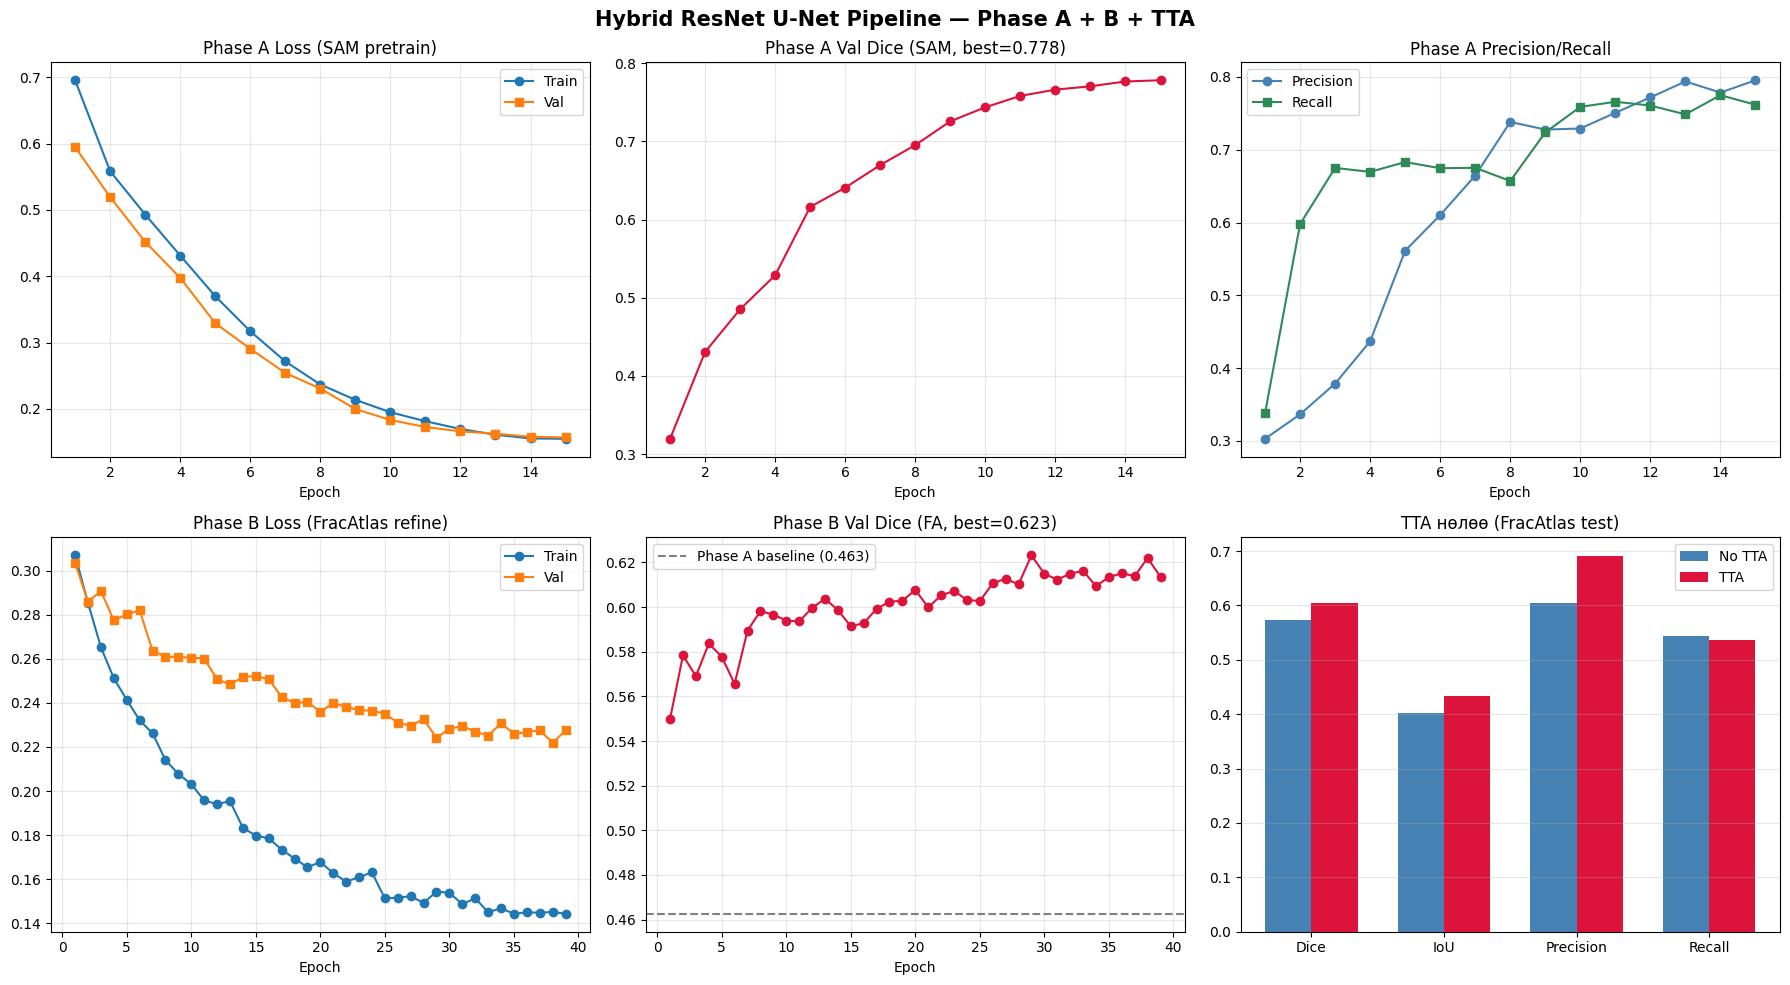

Drive дээр хадгалагдлаа: hybrid_curves.png ✓


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Phase A curves
epA = range(1, len(phase_a_history['train_loss']) + 1)
axes[0,0].plot(epA, phase_a_history['train_loss'], 'o-', label='Train')
axes[0,0].plot(epA, phase_a_history['val_loss'],   's-', label='Val')
axes[0,0].set_title('Phase A Loss (SAM pretrain)'); axes[0,0].set_xlabel('Epoch')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(epA, phase_a_history['val_dice'], 'o-', color='crimson')
axes[0,1].set_title(f'Phase A Val Dice (SAM, best={phase_a_best:.3f})')
axes[0,1].set_xlabel('Epoch'); axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(epA, phase_a_history['val_prec'], 'o-', label='Precision', color='steelblue')
axes[0,2].plot(epA, phase_a_history['val_rec'],  's-', label='Recall',    color='seagreen')
axes[0,2].set_title('Phase A Precision/Recall'); axes[0,2].set_xlabel('Epoch')
axes[0,2].legend(); axes[0,2].grid(True, alpha=0.3)

# Phase B curves
epB = range(1, len(phase_b_history['train_loss']) + 1)
axes[1,0].plot(epB, phase_b_history['train_loss'], 'o-', label='Train')
axes[1,0].plot(epB, phase_b_history['val_loss'],   's-', label='Val')
axes[1,0].set_title('Phase B Loss (FracAtlas refine)'); axes[1,0].set_xlabel('Epoch')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(epB, phase_b_history['val_dice'], 'o-', color='crimson')
axes[1,1].axhline(y=phase_a_test['dice'], color='gray', linestyle='--',
                  label=f'Phase A baseline ({phase_a_test["dice"]:.3f})')
axes[1,1].set_title(f'Phase B Val Dice (FA, best={phase_b_best:.3f})')
axes[1,1].set_xlabel('Epoch'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

# TTA comparison
metrics_names = ['Dice', 'IoU', 'Precision', 'Recall']
no_tta_vals = [test_no_tta[k] for k in ['dice','iou','precision','recall']]
tta_vals    = [test_tta[k]    for k in ['dice','iou','precision','recall']]
x = np.arange(len(metrics_names))
w = 0.35
axes[1,2].bar(x - w/2, no_tta_vals, w, label='No TTA', color='steelblue')
axes[1,2].bar(x + w/2, tta_vals,    w, label='TTA',    color='crimson')
axes[1,2].set_xticks(x); axes[1,2].set_xticklabels(metrics_names)
axes[1,2].set_title('TTA нөлөө (FracAtlas test)')
axes[1,2].legend(); axes[1,2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Hybrid ResNet U-Net Pipeline — Phase A + B + TTA', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hybrid_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Drive дээр хадгалагдлаа: hybrid_curves.png ✓')


## 10. Жишээ таамаглалууд (test split)

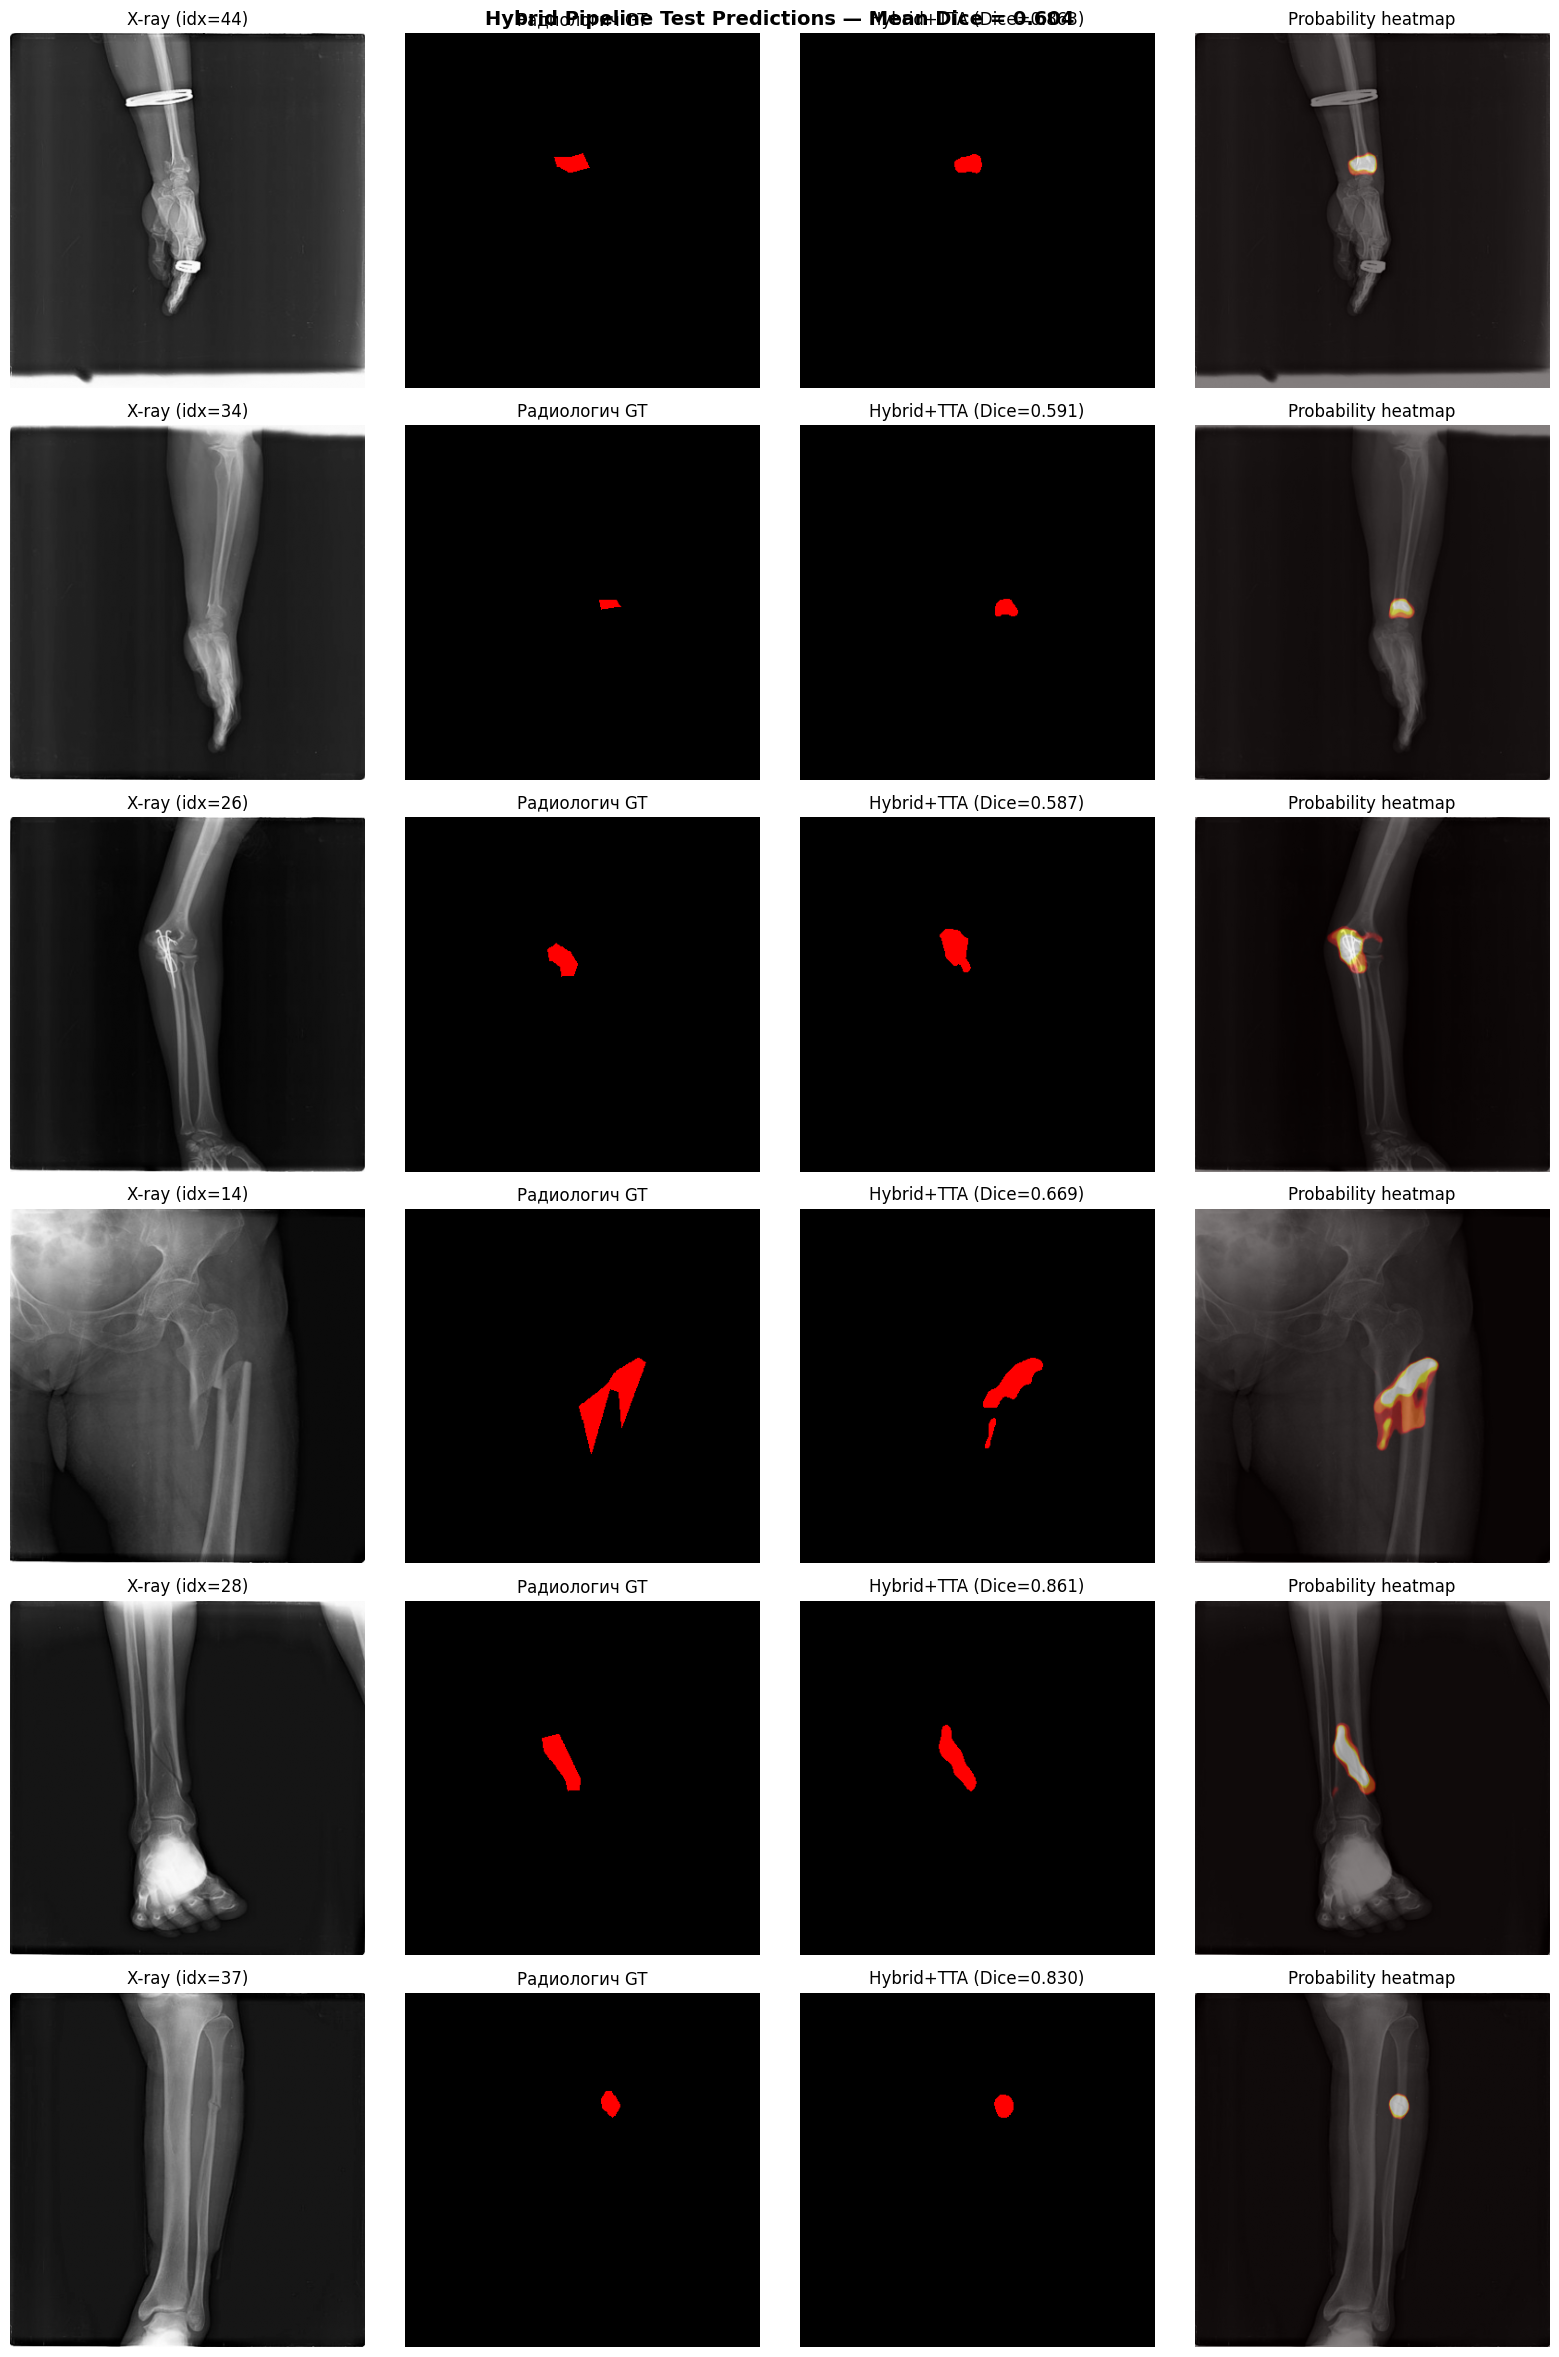

Drive дээр хадгалагдлаа: hybrid_predictions.png ✓


In [17]:
from matplotlib.colors import ListedColormap
SEG_CMAP = ListedColormap(['black', 'red'])

def visualize_predictions(n=6):
    candidates = []
    for i in range(len(fa_test_ds)):
        _, m = fa_test_ds[i]
        if m.sum() > 50:
            candidates.append(i)
    indices = random.sample(candidates, min(n, len(candidates))) if candidates else list(range(n))

    fig, axes = plt.subplots(len(indices), 4, figsize=(16, 4*len(indices)))
    if len(indices) == 1: axes = axes[None, :]

    model.eval()
    for r, idx in enumerate(indices):
        img, mask = fa_test_ds[idx]
        img_b = img.unsqueeze(0).to(device)
        with torch.no_grad():
            prob = predict_tta(model, img_b, tta=True)[0, 0].cpu().numpy()
        pred = (prob > TTA_THRESHOLD).astype(np.uint8)

        gt = mask[0].numpy()
        inter = ((pred == 1) & (gt == 1)).sum()
        union = (pred == 1).sum() + (gt == 1).sum()
        dice  = (2 * inter + 1e-6) / (union + 1e-6)

        # Зураг denormalize хийгээд харах
        img_show = img.permute(1,2,0).numpy() * IMAGENET_STD + IMAGENET_MEAN
        img_show = np.clip(img_show, 0, 1)
        img_gray = img_show[..., 0]  # 1 channel ашиглах (X-ray бараг grayscale)

        axes[r,0].imshow(img_gray, cmap='gray'); axes[r,0].set_title(f'X-ray (idx={idx})')
        axes[r,1].imshow(gt,   cmap=SEG_CMAP, vmin=0, vmax=1)
        axes[r,1].set_title('Радиологич GT')
        axes[r,2].imshow(pred, cmap=SEG_CMAP, vmin=0, vmax=1)
        axes[r,2].set_title(f'Hybrid+TTA (Dice={dice:.3f})')
        axes[r,3].imshow(img_gray, cmap='gray')
        axes[r,3].imshow(prob, cmap='hot', alpha=0.5, vmin=0, vmax=1)
        axes[r,3].set_title('Probability heatmap')
        for ax in axes[r]: ax.axis('off')

    plt.suptitle(f'Hybrid Pipeline Test Predictions — Mean Dice = {test_tta["dice"]:.3f}',
                  fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/hybrid_predictions.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Drive дээр хадгалагдлаа: hybrid_predictions.png ✓')

visualize_predictions(6)


## 11. Эцсийн дүгнэлт

In [18]:
print(f'\n{"="*68}')
print(f'  HYBRID PIPELINE — ЭЦСИЙН ҮР ДҮН')
print(f'{"="*68}')
print(f'  Архитектур         : U-Net + {ENCODER} ({ENCODER_WEIGHTS} pretrained)')
print(f'  Параметрийн тоо    : {total_params:.1f}M')
print(f'  Phase A (SAM)      : {len(sam_train_ids)} train, best val Dice = {phase_a_best:.4f}')
print(f'  Phase B (FracAtlas): {len(fa_train_ds)} train, best val Dice = {phase_b_best:.4f}')
print(f'  Test (TTA-ГҮЙ)     : Dice = {test_no_tta["dice"]:.4f}')
print(f'  Test (TTA-ТАЙ)     : Dice = {test_tta["dice"]:.4f} ⭐')
print(f'\n  Хадгалсан файлууд:')
print(f'    Phase A    : {PRETRAIN_SAVE}')
print(f'    Phase B    : {FINAL_SAVE}')
print(f'    Графикууд  : /content/drive/MyDrive/hybrid_{{curves,predictions}}.png')

# Thesis-д бичих өгүүлбэр
print(f'\n{"="*68}')
print(f'  ')
print(f'{"="*68}')
print(f'''
  "Бид ResNet50 ImageNet pretrained encoder бүхий U-Net загвар дээр
   2-шаттай finetuning ашиглав: эхлээд 3K SAM-аар үүсгэсэн pseudo-маск
   дээр pretrain (Phase A, Dice {phase_a_test['dice']:.3f}), дараа нь FracAtlas-ийн
   {len(fa_train_ds)} радиологичын маск дээр refine (Phase B). Test-time
   augmentation (TTA)-тай хослуулснаар FracAtlas test split-д
   эцсийн Dice {test_tta['dice']:.3f} хүрэв.

   Энэ нь бидний өмнөх diffusion-based архитектурын үр дүнгээс ({0.1562:.3f})
   {(test_tta['dice']/0.1562-1)*100:+.0f}% ахисан үр дүн юм, мөн уг
   архитектурын сонголт нь fracture segmentation-д хамгийн чухал хүчин
   зүйл болохыг харуулж байна."
''')



  HYBRID PIPELINE — ЭЦСИЙН ҮР ДҮН
  Архитектур         : U-Net + resnet50 (imagenet pretrained)
  Параметрийн тоо    : 32.5M
  Phase A (SAM)      : 3041 train, best val Dice = 0.7782
  Phase B (FracAtlas): 574 train, best val Dice = 0.6232
  Test (TTA-ГҮЙ)     : Dice = 0.5731
  Test (TTA-ТАЙ)     : Dice = 0.6041 ⭐

  Хадгалсан файлууд:
    Phase A    : /content/drive/MyDrive/hybrid_unet_pretrain.pth
    Phase B    : /content/drive/MyDrive/hybrid_unet_final.pth
    Графикууд  : /content/drive/MyDrive/hybrid_{curves,predictions}.png

  
  
  "Бид ResNet50 ImageNet pretrained encoder бүхий U-Net загвар дээр
   2-шаттай finetuning ашиглав: эхлээд 3K SAM-аар үүсгэсэн pseudo-маск
   дээр pretrain (Phase A, Dice 0.463), дараа нь FracAtlas-ийн
   574 радиологичын маск дээр refine (Phase B). Test-time
   augmentation (TTA)-тай хослуулснаар FracAtlas test split-д
   эцсийн Dice 0.604 хүрэв.

   Энэ нь бидний өмнөх diffusion-based архитектурын үр дүнгээс (0.156)
   +287% ахисан үр дүн юм, мөн уг